In [45]:
import seaborn as sns

base_fontsize = 22
sns.set_theme(
    style="ticks",
    rc={
        "font.size": base_fontsize,
        "axes.titlesize": base_fontsize,
        "axes.labelsize": base_fontsize,
        "xtick.labelsize": base_fontsize * 0.85,
        "ytick.labelsize": base_fontsize * 0.85,
        "legend.title_fontsize": base_fontsize * 0.9,
        "legend.fontsize": base_fontsize * 0.9,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "hatch.linewidth": 1.5,
        "hatch.color": "#333333",
    },
)


def apply_hatches(g, hatch_map):
    """Apply hatches by matching legend colors to bars."""
    # Build color -> hatch from legend
    color_to_hatch = {}
    for text, handle in zip(g._legend.get_texts(), g._legend.legend_handles):
        hatch = hatch_map.get(text.get_text(), None)
        if hatch:
            fc = handle.get_facecolor()
            color_to_hatch[tuple(fc)] = hatch

    # Apply to all bars
    for ax in g.axes.flat:
        for bar in ax.patches:
            hatch = color_to_hatch.get(tuple(bar.get_facecolor()))
            if hatch:
                bar.set_hatch(hatch)
                bar.set_edgecolor("#333333")

## Figure 4. Performance on ViT/T5

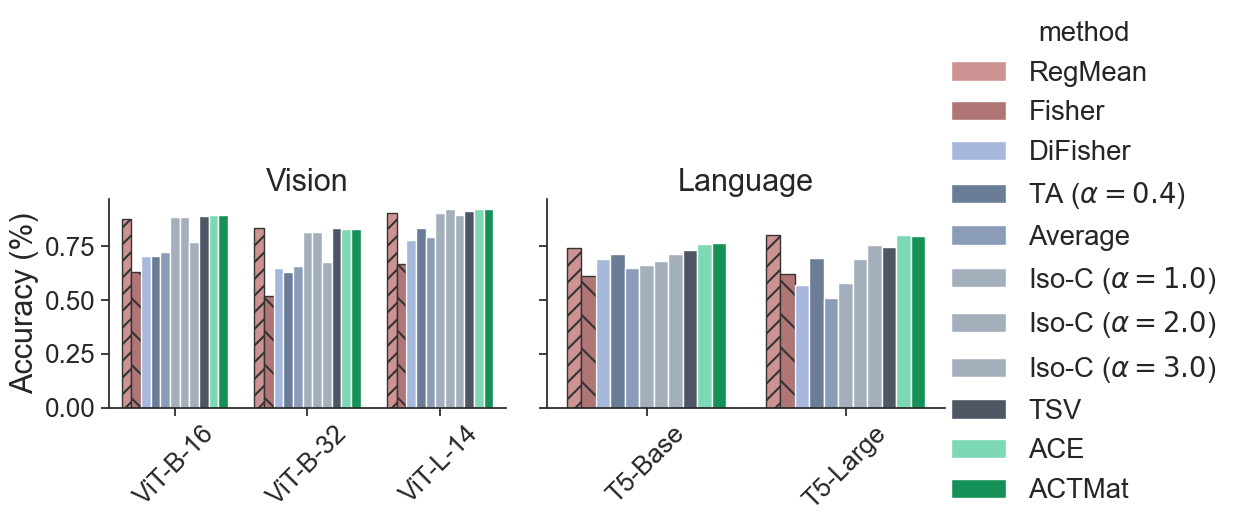

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import seaborn as sns

methods = [
    "zeroshot",
    "experts",
    "regmean",
    "fisher",
    "difisher",
    "difisher_v2",
    "sum04",
    "mean",
    "isoc",
    "isoc2",
    "isoc3",
    "tsv",
    "ace",
    "eigcov",
]
models = ["ViT-B-16", "ViT-B-32", "ViT-L-14", "T5-Base", "T5-Large"]

method_to_method = {
    "zeroshot": "Zero-shot",
    "experts": "Experts",
    "regmean": "RegMean",
    "fisher": "Fisher",
    "difisher": "DiFisher",
    "difisher_v2": "DiFisher-v2",
    "sum04": "TA ($\\alpha=0.4$)",
    "mean": "Average",
    "isoc": "Iso-C ($\\alpha=1.0$)",
    "isoc2": "Iso-C ($\\alpha=2.0$)",
    "isoc3": "Iso-C ($\\alpha=3.0$)",
    "tsv": "TSV",
    "eigcov": "ACTMat",
    "ace": "ACE",
}
method_to_color = {
    "RegMean": "#CBD5E0",
    "Fisher": "#B4C2CE",
    "TA ($\\alpha=0.4$)": "#E2E8F0",
    "Average": "#A0AEC0",
    # "Iso-C ($\\alpha=1.0$)": "#718096",
    # "Iso-C ($\\alpha=2.0$)": "#4A5568",
    "Iso-C ($\\alpha=1.0$)": "#FFA500",  # orange
    "Iso-C ($\\alpha=2.0$)": "#FF0000",  # red
    "Iso-C ($\\alpha=3.0$)": "#800080",  # purple
    "KNOTS-Iso-C": "#718096",
    "TSV": "#4A5568",
    "KNOTS-TSV": "#4A5568",
    "ACE": "#6EE7B7",  # lighter green
    "ACTMat": "#00A658",
}

method_to_color = {
    # Base/Reference (Muted Gray)
    "Zero-shot": "#B0B0B0",
    # Group 1: Data-Dependent Methods (Muted Reds/Terracottas)
    "RegMean": "#D68A8A",
    "Fisher": "#BA6B6B",
    "DiFisher": "#9DB7E5",
    "DiFisher-v2": "#9DB7E5",
    # Group 2: Merging/Ensembling Baselines (Muted Blues)
    "Experts": "#A3B7D9",
    "Average": "#829ABF",
    "TA ($\\alpha=0.4$)": "#637B9D",
    # Group 3: Task Vectors, Iso-C, and KNOTS Variants (Muted Slates)
    "Iso-C ($\\alpha=1.0$)": "#A0AEC0",  # Lighter slate to complete the family progression
    "Iso-C ($\\alpha=2.0$)": "#A0AEC0",  # Lighter slate to complete the family progression
    "Iso-C ($\\alpha=3.0$)": "#A0AEC0",  # Lighter slate to complete the family progression
    "KNOTS-Iso-C": "#718096",  # (User specified)
    "TSV": "#4A5568",  # (User specified)
    "KNOTS-TSV": "#4A5568",  # (User specified) - Note: Use "#2D3748" if you need it darker/distinct
    # Group 4: ActMat (Muted Gold/Mustard)
    "ACE": "#6EE7B7",  # lighter green
    "ACTMat": "#00A658",
}

method_to_hatch = {
    "TA": "//",
    "RegMean": "//",
    "Fisher": "\\",
}

method_to_linestyle = {
    "Experts": "-",
    "Zero-shot": ".",
}

model_to_group = {
    "ViT-B-16": "Vision",
    "ViT-B-32": "Vision",
    "ViT-L-14": "Vision",
    "T5-Base": "Language",
    "T5-Large": "Language",
}

rows = []
for model in models:
    for method in methods:

        filename = f"../results/{model}-{method}/metrics.json"
        if not os.path.exists(filename):
            continue

        # print(f"Loading {filename}")
        with open(filename, "r") as f:
            metrics = json.load(f)
            scores = [t["metrics"]["primary_score"] for t in metrics["tasks"]]
            avg_score = np.mean(scores)
            rows.append({"model": model, "method": method, "acc": avg_score})


df = pd.DataFrame(rows)
df["group"] = df["model"].map(lambda x: model_to_group[x])
df["method"] = df["method"].map(lambda x: method_to_method[x])
# display(df)
g = sns.catplot(
    data=df,
    x="model",
    hue="method",
    y="acc",
    col="group",
    kind="bar",
    palette=method_to_color,
    sharex=False,
)
# Formatting.
g.set_axis_labels("", "Accuracy (%)")
g.set_xticklabels(rotation=45)
g.set_titles("{col_name}", fontsize=base_fontsize)

# # Legend.
# g._legend.remove()
# g.fig.legend(
#     *g.axes.flat[0].get_legend_handles_labels(),
#     loc="lower center",
#     ncol=4,
#     bbox_to_anchor=(0.5, -0.1),
#     title="",
#     frameon=False,
# )
# g.fig.subplots_adjust(bottom=0.35)
apply_hatches(g, method_to_hatch)
# apply_linestyles(g, method_to_linestyle)

In [40]:
dfp = df.pivot(index="method", columns="model", values="acc")
dfp = (dfp * 100).round(1)
# filter: only include methods with substring Iso-C
# dfp = dfp[dfp.index.str.contains("Iso-C")]
# Only include "Average" and "Fisher"
dfp = dfp[dfp.index.isin(["Average", "Fisher", "DiFisher", "DiFisher-v2"])]
dfp.sort_values(by="ViT-B-16")

model,T5-Base,T5-Large,ViT-B-16,ViT-B-32,ViT-L-14
method,,,,,
Fisher,61.0,62.0,62.9,52.0,66.7
DiFisher,69.1,57.1,70.5,64.7,77.5
Average,64.8,50.9,72.2,65.4,79.3


In [52]:
import torch


def cosine_similarity(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    return torch.dot(a.flatten(), b.flatten()) / (a.norm() * b.norm())


model = "ViT-B-16"
checkpoints_dir = f"../analysis-checkpoints/{model}/max_steps_10"
results_dir = f"../analysis-results/{model}"
os.makedirs(results_dir, exist_ok=True)

datasets = [
    "Cars",
    "DTD",
    "EuroSAT",
    "GTSRB",
    "MNIST",
    "RESISC45",
    "SUN397",
    "SVHN",
]

rows = []
for d in datasets:
    for filename in os.listdir(os.path.join(checkpoints_dir, d + "Val")):
        if not "grad_cross" in filename:
            continue
        layer_name = filename.replace(".pt", "").replace(
            "grad_cross_matrix_model_visual_transformer_resblocks_", ""
        )
        gcm = torch.load(os.path.join(checkpoints_dir, d + "Val", filename))
        cosim_cross = cosine_similarity(gcm["gbar"].T @ gcm["gbar"], gcm["sbar"])
        cosim_corr = cosine_similarity(gcm["sbar"], gcm["stilde"])
        # BUG: just for testing for now
        cov_terminal = torch.randn_like(gcm["sbar"])
        cosim_drift = cosine_similarity(gcm["sbar"], cov_terminal)
        rows.extend(
            [
                {
                    "dataset": d,
                    "layer_name": layer_name,
                    "cosine_similarity": cosim_cross.item(),
                    "type": "cross",
                },
                {
                    "dataset": d,
                    "layer_name": layer_name,
                    "cosine_similarity": cosim_corr.item(),
                    "type": "corr",
                },
                {
                    "dataset": d,
                    "layer_name": layer_name,
                    "cosine_similarity": cosim_drift.item(),
                    "type": "drift",
                },
            ]
        )

df = pd.DataFrame(rows)
df.to_csv(os.path.join(results_dir, "error_terms.csv"), index=False)

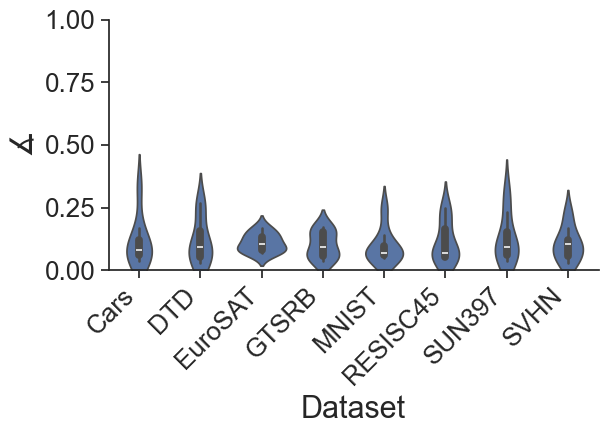

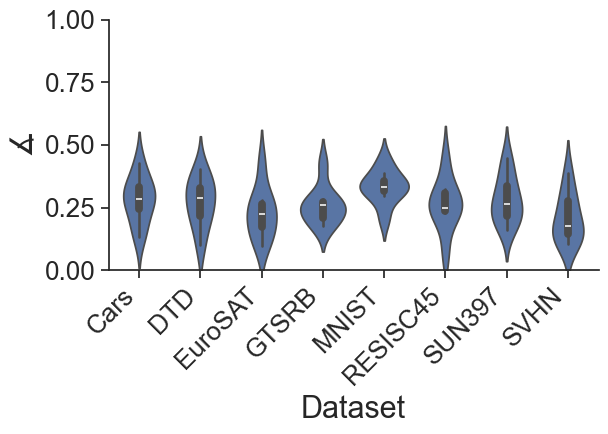

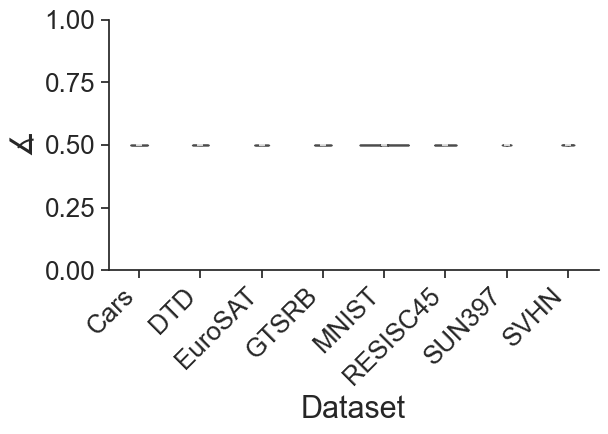

In [55]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

model = "ViT-B-16"
results_dir = f"../analysis-results/{model}"

# for loop. plot and save each violin plot

for type in ["cross", "corr", "drift"]:

    # Compute angular distance: https://en.wikipedia.org/wiki/Cosine_similarity
    df = pd.read_csv(os.path.join(results_dir, "error_terms.csv"))
    df["angular_distance"] = np.arccos(df["cosine_similarity"].clip(-1.0, 1.0)) / np.pi
    df = df[df["type"] == type]

    # Make violin plot
    plt.figure()
    sns.violinplot(data=df, x="dataset", y="angular_distance")
    plt.ylim(0, 1)  # Set y-axis range from 0 to 1
    plt.ylabel(r"$\measuredangle$")
    plt.xlabel("Dataset")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(
        os.path.join(results_dir, f"error_{type}_term.pdf"), bbox_inches="tight"
    )
    plt.show()
    plt.close()